In [26]:
#  Imports and settings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Added OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, classification_report)

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid')
RANDOM_STATE = 42

In [3]:
df = pd.read_excel("/content/default of credit card clients.xls",skiprows=1)

# If the dataset has an extra index column named 'ID' or 'Unnamed: 0', drop it:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head(10)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


In [4]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


# 1. Perform Exploratory Data Analysis (EDA):
o Understand and visualize relationships between client features and default
behaviour.  
o Identify class imbalances and outliers.

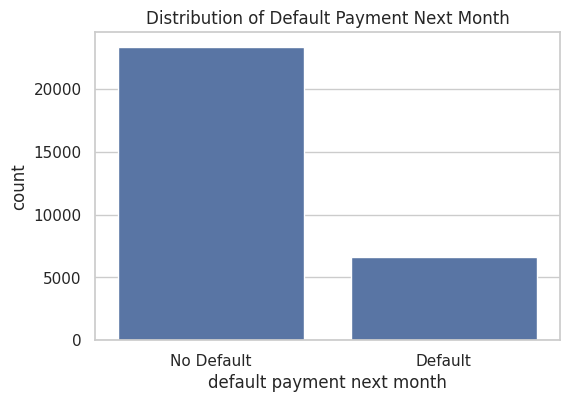

In [8]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))
sns.countplot(x='default payment next month', data=df)
plt.title('Distribution of Default Payment Next Month')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

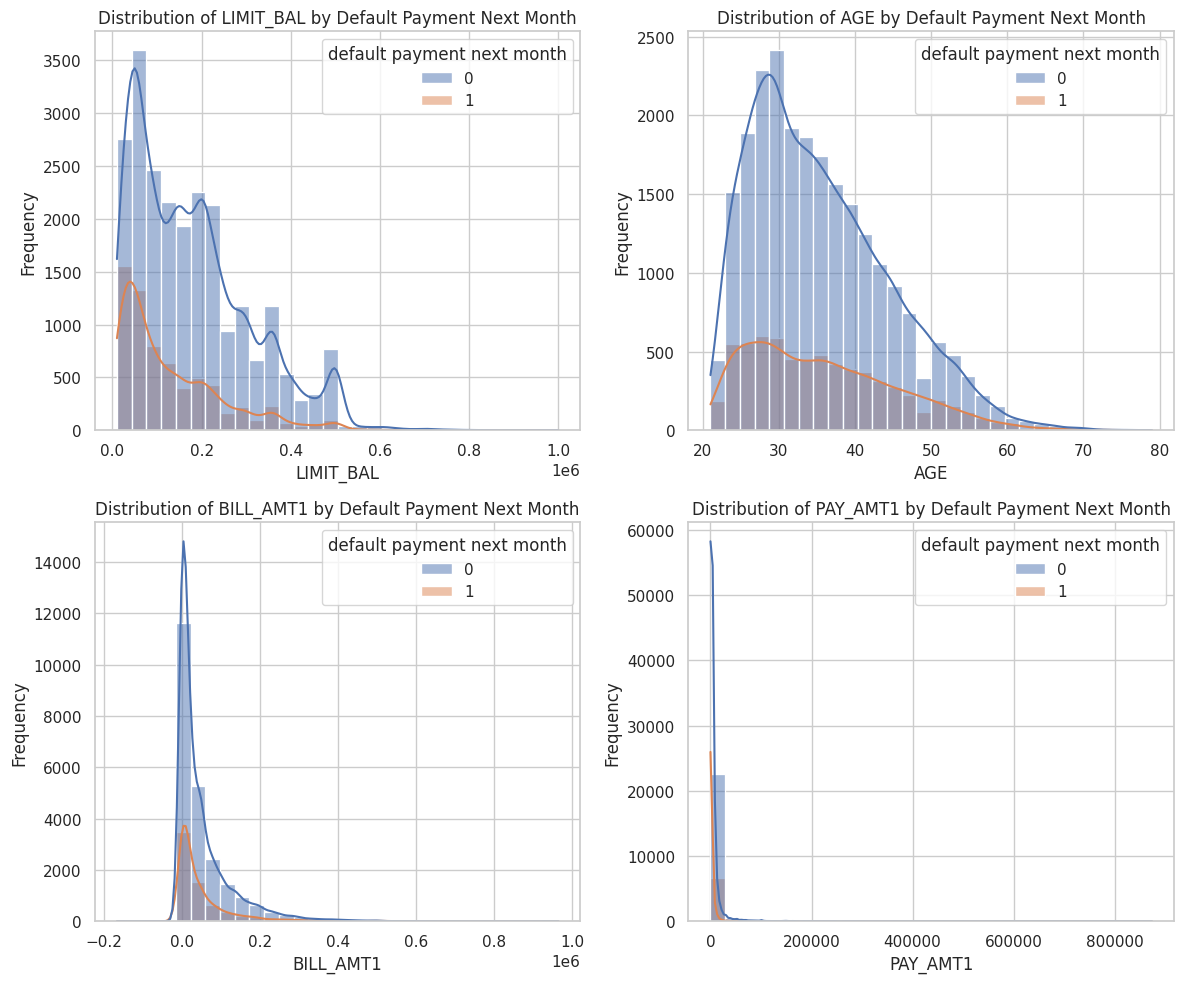

In [15]:
# Explore the relationship between numerical features and the target variable
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, hue='default payment next month', kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} by Default Payment Next Month')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

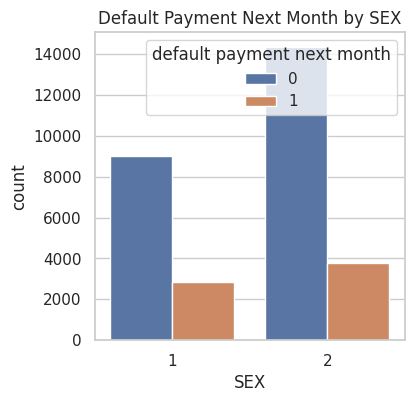

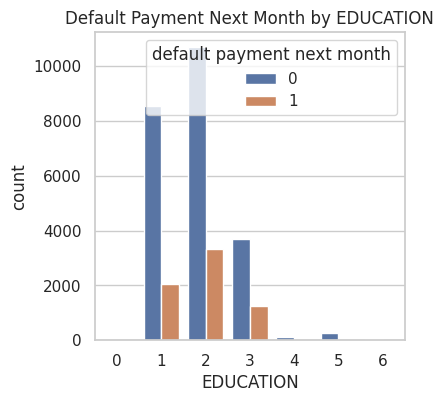

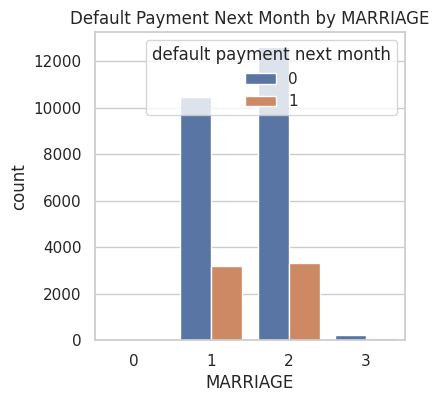

In [16]:
# Explore the relationship between categorical features and the target variable
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']

for feature in categorical_features:
    plt.figure(figsize=(4,4))
    sns.countplot(x=feature, hue='default payment next month', data=df)
    plt.title(f'Default Payment Next Month by {feature}')
    plt.xticks(rotation=0)
    plt.show()

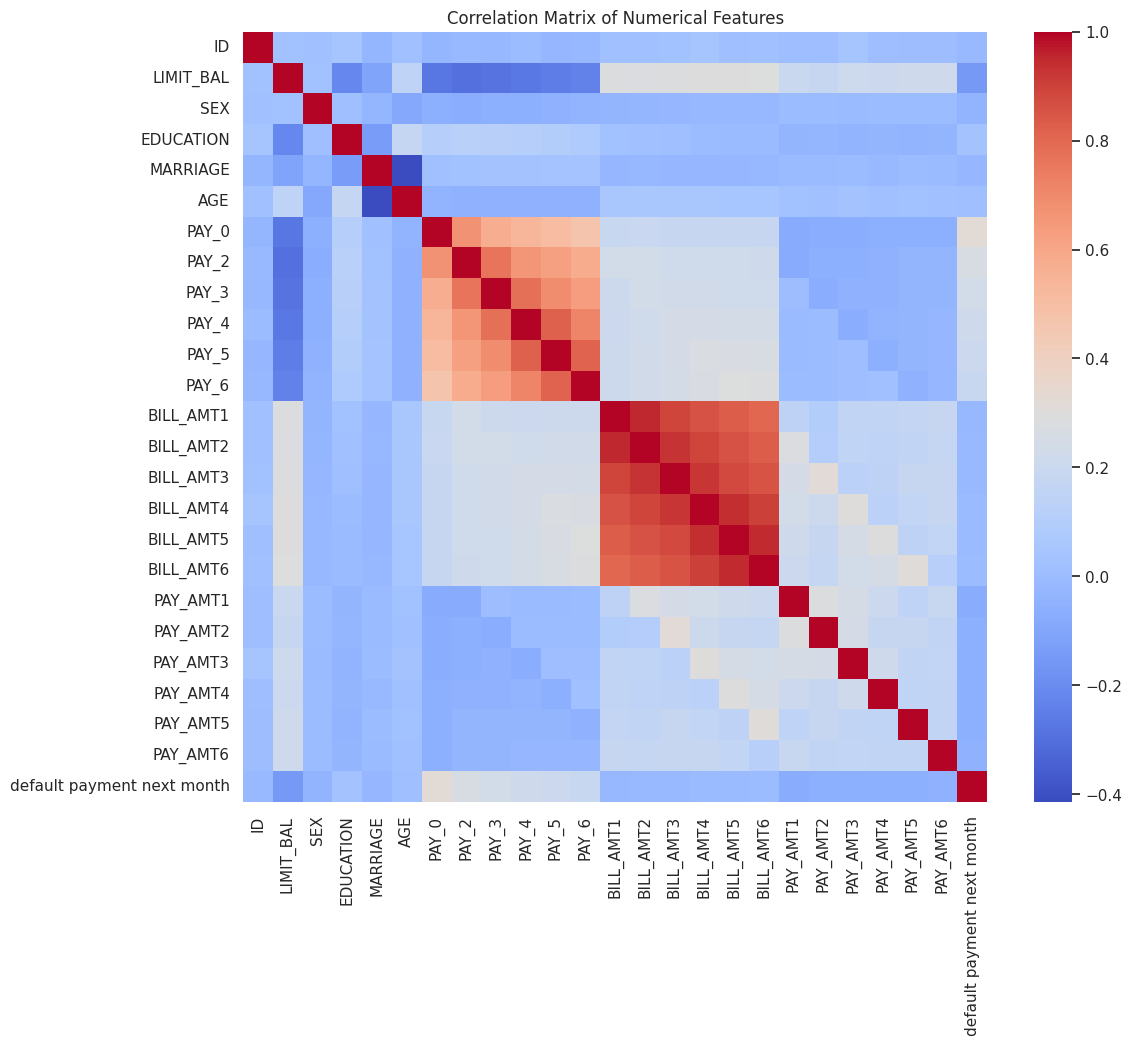

In [12]:
# Explore correlations between numerical features
numerical_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

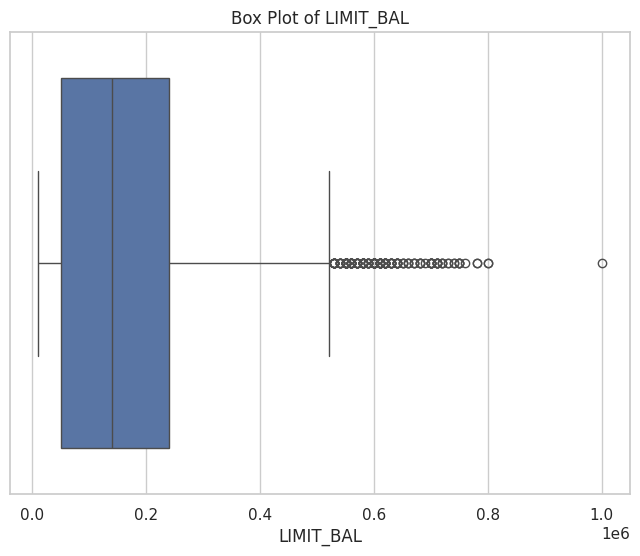

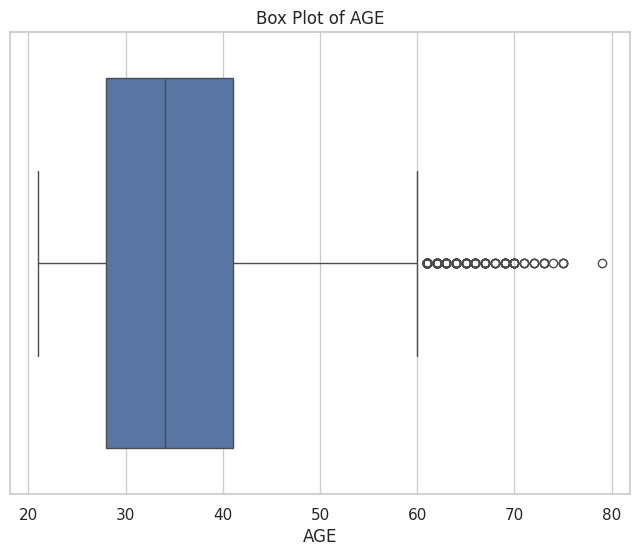

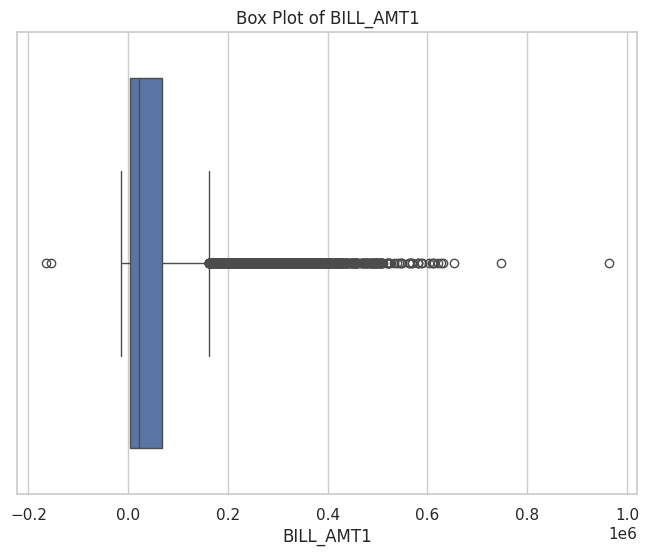

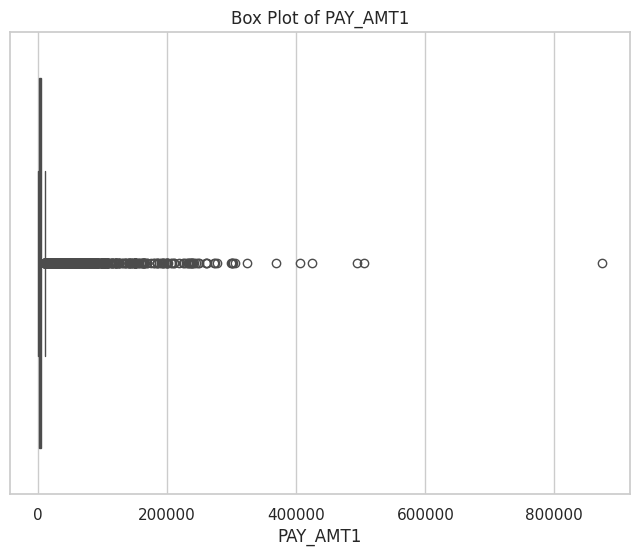

In [17]:
# Identify outliers in numerical features using box plots
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
    plt.show()

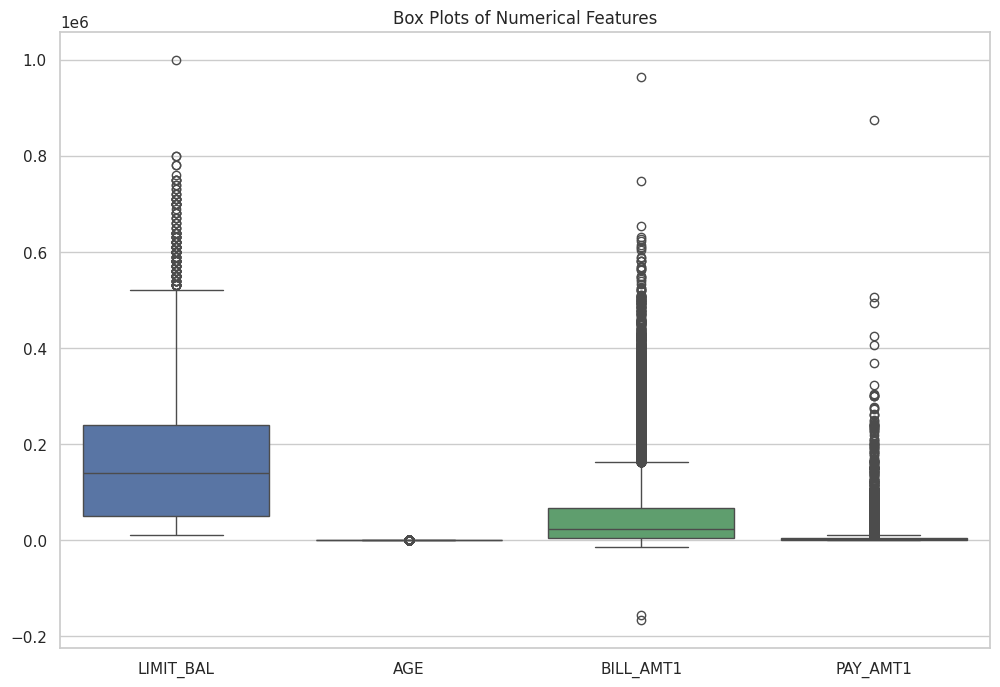

In [21]:
# Identify outliers in numerical features using box plots
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

plt.figure(figsize=(12, 8))
sns.boxplot(data=df[numerical_features])
plt.title('Box Plots of Numerical Features')
plt.show()

2. Preprocess the Data:  
o Handle missing or inconsistent data.  
o Encode categorical variables and normalize/scale numerical features if
necessary.

In [24]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64


In [29]:
# Separate features and target variable
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

# Identify categorical and numerical features
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
# Assuming all other columns except 'ID' and the target are numerical for now.
# A more robust approach would be to explicitly define or infer based on dtypes.
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
numerical_features.remove('ID')
numerical_features = [col for col in numerical_features if col not in categorical_features]


# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Although no missing values found, including for robustness
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like 'ID') - decide if this is needed later
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Display the shape of the processed data
print("Shape of processed data:", X_processed.shape)

Shape of processed data: (30000, 32)


In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (24000, 32)
Shape of X_test: (6000, 32)
Shape of y_train: (24000,)
Shape of y_test: (6000,)


3. Build Classification Models:  
o Train and evaluate a Decision Tree Classifier  
o Train and evaluate a Logistic Regression model

In [32]:
# Train and evaluate a Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Classifier Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Classifier Performance:
Accuracy: 0.726
Precision: 0.38621679827709976
Recall: 0.4054257724189902
F1 Score: 0.39558823529411763

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82      4673
           1       0.39      0.41      0.40      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.73      0.73      6000



In [33]:
# Train and evaluate a Logistic Regression model
lr_model = LogisticRegression(random_state=RANDOM_STATE)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Performance:
Accuracy: 0.8073333333333333
Precision: 0.6879120879120879
Recall: 0.23587038432554636
F1 Score: 0.35129068462401797

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.35      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



4. Optimize Using Cross-Validation:  
o Use k-fold cross-validation to tune model parameters and assess robustness.

In [34]:
# Use k-fold cross-validation to assess the robustness of the Decision Tree model
k = 5  # Number of folds
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'] # Metrics to evaluate

cv_results_dt = cross_validate(dt_model, X_processed, y, cv=k, scoring=scoring)

print(f"Cross-validation results for Decision Tree ({k}-fold):")
for metric in scoring:
    mean_score = cv_results_dt[f'test_{metric}'].mean()
    std_score = cv_results_dt[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: Mean = {mean_score:.4f}, Std Dev = {std_score:.4f}")

Cross-validation results for Decision Tree (5-fold):
Accuracy: Mean = 0.6845, Std Dev = 0.0420
Precision: Mean = 0.3273, Std Dev = 0.0503
Recall: Mean = 0.3840, Std Dev = 0.0603
F1: Mean = 0.3502, Std Dev = 0.0470
Roc_auc: Mean = 0.5769, Std Dev = 0.0340


In [35]:
# Use k-fold cross-validation to assess the robustness of the Logistic Regression model
k = 5  # Number of folds
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'] # Metrics to evaluate

cv_results_lr = cross_validate(lr_model, X_processed, y, cv=k, scoring=scoring)

print(f"\nCross-validation results for Logistic Regression ({k}-fold):")
for metric in scoring:
    mean_score = cv_results_lr[f'test_{metric}'].mean()
    std_score = cv_results_lr[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: Mean = {mean_score:.4f}, Std Dev = {std_score:.4f}")


Cross-validation results for Logistic Regression (5-fold):
Accuracy: Mean = 0.8067, Std Dev = 0.0054
Precision: Mean = 0.6902, Std Dev = 0.0562
Recall: Mean = 0.2491, Std Dev = 0.0776
F1: Mean = 0.3553, Std Dev = 0.0782
Roc_auc: Mean = 0.7190, Std Dev = 0.0174


5. Evaluate and Compare Models:  
o Use metrics like Accuracy, Precision, Recall, F1-Score, AUC-ROC Curve, and
Confusion Matrix.

Confusion Matrix for Decision Tree:
[[3818  855]
 [ 789  538]]

Confusion Matrix for Logistic Regression:
[[4531  142]
 [1014  313]]


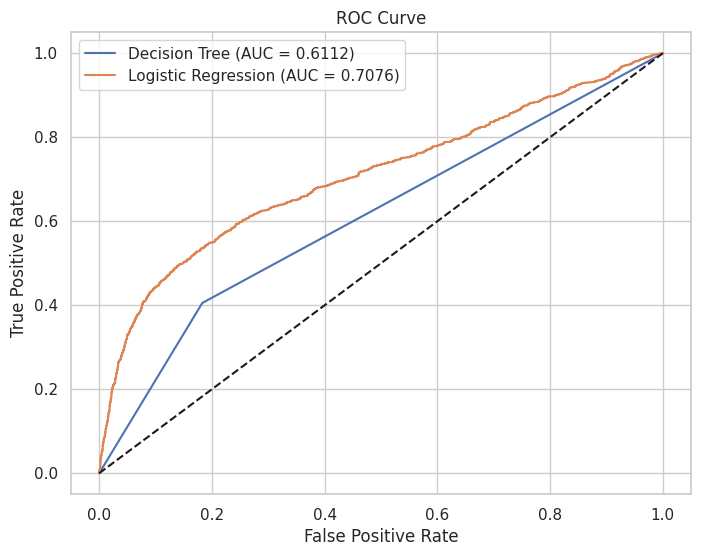

In [37]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
print("Confusion Matrix for Decision Tree:")
print(cm_dt)

# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix for Logistic Regression:")
print(cm_lr)

# AUC-ROC Curve for Decision Tree
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.4f})')

# AUC-ROC Curve for Logistic Regression
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})')

plt.plot([0, 1], [0, 1], 'k--') # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

6. Provide Insights and Recommendations:  
o Highlight which features are most predictive of default risk.  
o Discuss practical applications (e.g., improving risk management or targeting
intervention policies).

In [38]:
# Provide Insights and Recommendations

# Highlight which features are most predictive of default risk using Decision Tree feature importances
# Need to get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()
feature_importances = dt_model.feature_importances_

# Create a pandas Series for easier handling
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance
sorted_importance = importance_series.sort_values(ascending=False)

print("Top 10 Most Predictive Features (from Decision Tree):")
print(sorted_importance.head(10))

# Discuss practical applications in a markdown cell

Top 10 Most Predictive Features (from Decision Tree):
num__PAY_0        0.159671
remainder__ID     0.090910
num__BILL_AMT1    0.060611
num__AGE          0.060198
num__LIMIT_BAL    0.055065
num__PAY_AMT3     0.049376
num__PAY_AMT2     0.048540
num__PAY_AMT6     0.045854
num__PAY_AMT1     0.043575
num__PAY_AMT5     0.042233
dtype: float64


# Insights and Recommendations
Key predictors of default risk include repayment status, credit limit, and bill amounts. Client age and payment amounts are also significant. The unexpected importance of the ID column suggests a need for further investigation into its relationship with default.

## Practical Applications

Improved Risk Management: The model can help financial institutions more accurately assess credit risk and identify high-risk individuals.


* Targeted Intervention: Banks can create customized programs, such as financial counseling or tailored payment plans, for clients with specific repayment histories or credit limits to prevent default.


* Optimized Credit Offerings: Insights from the model can help attract and retain lower-risk customers by informing the design of credit products and services.

* Data Monitoring: The strong predictive power of repayment status emphasizes the need for continuous data collection and monitoring of client behavior.